# CTA Train Positions - Data Quality Inspections

A brief audit of the 'train_positions' dataset export from Railway. Covering roughly ~3.5M entries collected between 2026-07-15 and 2026-08-22.

In [30]:
import duckdb

con = duckdb.connect()
DATA_PATH = '../data/train_positions.parquet'

## Basic data structure and record count

In [31]:
con.execute(f"SELECT * FROM '{DATA_PATH}' LIMIT 5").fetchdf()

,run_number,line,direction,destination,next_station_id,next_station_name,next_stop_id,predicted_time,arrival_time,is_approaching,is_delayed,latitude,longitude,heading,polled_at
0,828,red,1,Howard,41420,Addison,30273,2026-07-14 19:54:42,2026-07-14 19:55:42,1,0,41.94743,-87.65363,359,2026-07-15 00:54:59.040463
1,829,red,1,Howard,41170,Garfield,30223,2026-07-14 19:54:36,2026-07-14 19:56:36,0,0,41.78236,-87.63104,358,2026-07-15 00:54:59.040463
2,830,red,1,Howard,40650,North/Clybourn,30125,2026-07-14 19:54:30,2026-07-14 19:56:30,0,0,41.90392,-87.63141,269,2026-07-15 00:54:59.040463
3,834,red,5,95th/Dan Ryan,40560,Jackson,30110,2026-07-14 19:53:34,2026-07-14 19:54:34,1,0,41.88074,-87.62770,178,2026-07-15 00:54:59.040463
4,837,red,5,95th/Dan Ryan,40880,Thorndale,30170,2026-07-14 19:54:35,2026-07-14 19:55:35,1,0,41.99026,-87.65908,177,2026-07-15 00:54:59.040463


In [32]:
con.execute(f"SELECT COUNT(*) FROM '{DATA_PATH}'").fetchdf()

,count_star()
0,3556074


## Time coverage

In [33]:
con.execute(f"""
    SELECT
        strftime(MIN(polled_at), '%Y-%m-%d %H:%M:%S') AS earliest_poll,
        strftime(MAX(polled_at), '%Y-%m-%d %H:%M:%S') AS latest_poll
    FROM '{DATA_PATH}'
""").fetchdf()

,earliest_poll,latest_poll
0,2026-07-15 00:54:59,2026-08-22 19:16:02


## Distribution across lines

Each line's share of records is roughly proportional to its physical size, as expected.

In [34]:
con.execute(f"""
    SELECT
        line,
        COUNT(*) AS record_count,
        COUNT(*)::DOUBLE / (SELECT COUNT(*) FROM '{DATA_PATH}') AS pct_of_total
    FROM '{DATA_PATH}'
    GROUP BY line
    ORDER BY record_count DESC
""").fetchdf()

,line,record_count,pct_of_total
0,blue,932508,0.262230
1,red,823915,0.231692
2,g,535698,0.150643
3,brn,434599,0.122213
4,org,295266,0.083031
5,pink,255471,0.071841
6,p,221122,0.062181
7,y,57495,0.016168


## Checking for NULLs and out-of-range values

In [35]:
con.execute(f"SUMMARIZE SELECT * FROM '{DATA_PATH}'").fetchdf()

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,run_number,VARCHAR,000,999,522,None,None,None,None,None,3556074,0.0
1,line,VARCHAR,blue,y,7,None,None,None,None,None,3556074,0.0
2,direction,VARCHAR,1,5,2,None,None,None,None,None,3556074,0.0
3,destination,VARCHAR,54th/Cermak,UIC-Halsted,22,None,None,None,None,None,3556074,0.0
4,next_station_id,VARCHAR,40010,41710,143,None,None,None,None,None,3556074,0.0
5,next_station_name,VARCHAR,18th,Wilson,99,None,None,None,None,None,3556074,0.0
6,next_stop_id,VARCHAR,30001,30388,272,None,None,None,None,None,3556074,0.0
7,predicted_time,TIMESTAMP,2026-07-14 19:45:35,2026-08-22 14:15:42,1695534,2026-08-03 07:08:46.871731,None,2026-07-24 12:21:53.708782,2026-08-03 10:39:58.698011,2026-08-13 01:24:19.500474,3556074,0.0
8,arrival_time,TIMESTAMP,2026-07-14 19:46:35,2026-08-22 14:20:22,1819239,2026-08-03 07:10:27.92753,None,2026-07-24 12:51:05.784417,2026-08-03 12:47:36.702281,2026-08-13 01:48:19.539888,3556074,0.0
9,is_approaching,INTEGER,0,1,2,0.554321704216504,0.49704046306460603,0,1,1,3556074,0.0


In [36]:
# latitude/longitude of exactly 0 is outside of Chicago, representing a record without true GPS coordinates
con.execute(f"SELECT COUNT(*) FROM '{DATA_PATH}' WHERE latitude = 0 OR longitude = 0").fetchdf()

,count_star()
0,37730


37,730 rows in our initial data have both `latitude = 0` and `longitude = 0`. This represents a response from the API without GPS coordinates. Due to this quirk, we have updated `collector.py` to substitute such entries with 'NULL', and the existing entries will be cleaned later.

## Sanity checking non-zero latitude and longitude values visually

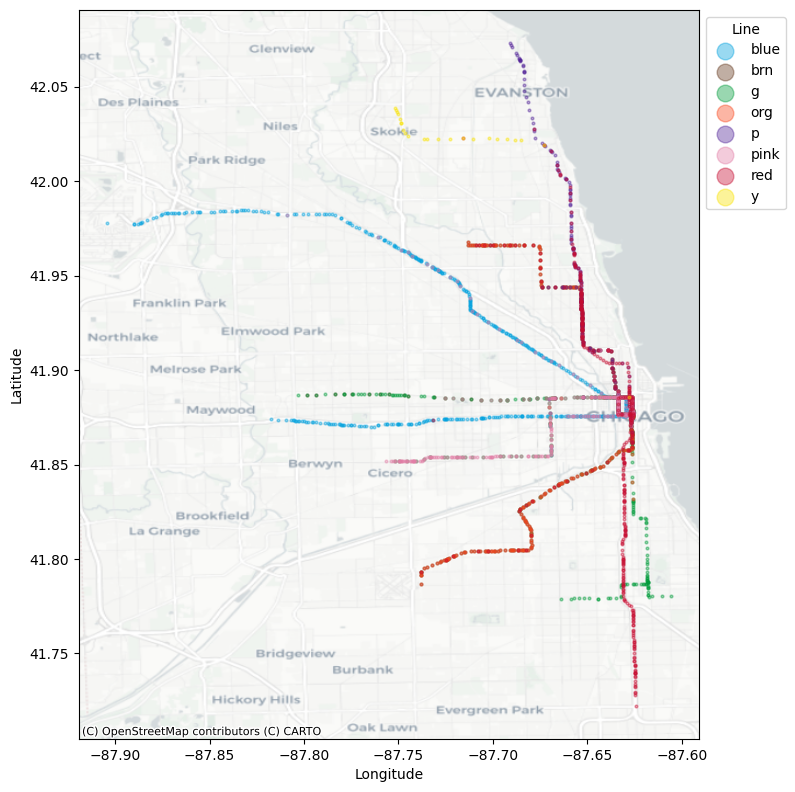

In [37]:
positions = con.execute(f"""
    SELECT DISTINCT line, latitude, longitude
    FROM '{DATA_PATH}'
    WHERE latitude != 0 AND longitude != 0
""").df()

import matplotlib.pyplot as plt
import contextily as cx

CTA_LINE_COLORS = {
    "red": "#C60C30",
    "blue": "#00A1DE",
    "brn": "#62361B",
    "g": "#009B3A",
    "org": "#F9461C",
    "p": "#522398",
    "pink": "#E27EA6",
    "y": "#F9E300",
}

_, ax = plt.subplots(figsize=(8, 10))

for line, group in positions.groupby("line"):
    ax.scatter(
        group["longitude"], group["latitude"],
        s=4, alpha=0.4,
        color=CTA_LINE_COLORS.get(line, "#888888"),
        label=line,
    )

# Add a basemap of Chicago for reference
cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.legend(markerscale=6, title="Line", loc="upper left", bbox_to_anchor=(1, 1))

plt.show()

## Check `direction`, `is_delayed`, and `is_approaching` for invalid values

In [38]:
con.execute(f"""
    SELECT
        COUNT(*) FILTER (WHERE direction NOT IN (1, 5)) AS invalid_direction,
        COUNT(*) FILTER (WHERE is_delayed NOT IN (0, 1)) AS invalid_is_delayed,
        COUNT(*) FILTER (WHERE is_approaching NOT IN (0, 1)) AS invalid_is_approaching
    FROM '{DATA_PATH}'
""").df()

,invalid_direction,invalid_is_delayed,invalid_is_approaching
0,0,0,0


## Checking for duplicate records

In [39]:
# a duplicate is the same train reported twice for the same poll
con.execute(f"""
    SELECT COUNT(*) AS duplicate_groups
    FROM (
        SELECT run_number, line, polled_at
        FROM '{DATA_PATH}'
        GROUP BY run_number, line, polled_at
        HAVING COUNT(*) > 1
    )
""").fetchdf()

,duplicate_groups
0,0


## Understanding `run_number` scope

`run_number` looks to be unique to a specific train on a per-day basis. Checking here to see if the same `run_number` is ever associated with more than one line, anywhere in the dataset.

In [40]:
con.execute(f"""
    SELECT run_number, COUNT(DISTINCT line) AS distinct_lines
    FROM '{DATA_PATH}'
    GROUP BY run_number
    HAVING COUNT(DISTINCT line) > 1
    ORDER BY distinct_lines DESC
""").fetchdf()

,run_number,distinct_lines
0,1000,8
1,1001,8
2,1002,7
3,707,3
4,713,3
...,...,...
63,418,2
64,1003,2
65,407,2
66,415,2


In [41]:
con.execute(f"""
    WITH run_lines AS (
        SELECT run_number, list_sort(array_agg(DISTINCT line)) AS lines
        FROM '{DATA_PATH}'
        GROUP BY run_number
        HAVING COUNT(DISTINCT line) > 1
    )
    SELECT lines, COUNT(*) AS num_run_numbers
    FROM run_lines
    GROUP BY lines
    ORDER BY num_run_numbers DESC
""").fetchdf()

,lines,num_run_numbers
0,"[brn, org]",49
1,"[p, y]",5
2,"[blue, pink]",4
3,"[blue, brn, org]",3
4,"[brn, org, red]",2
5,"[blue, brn, g, org, p, pink, red, y]",2
6,"[brn, pink]",1
7,"[blue, brn, g, p, pink, red, y]",1
8,"[g, p]",1


**TODO:** `[brn, org]` is far more common than the other combinations. This needs to be investigated further.

Several `run_number` values are used across different lines, so we will have to be sure to filter by both line (and also the date recorded) when reconstructing individual journeys of a particular train.

## Check for gaps in polling

In [42]:
# Check for gaps greater than 2 minutes between records
con.execute(f"""
    WITH poll_times AS (
        SELECT DISTINCT polled_at
        FROM '{DATA_PATH}'
    ),
    gaps AS (
        SELECT
            polled_at,
            date_diff('second', LAG(polled_at) OVER (ORDER BY polled_at), polled_at) AS gap_seconds
        FROM poll_times
    )
    SELECT *
    FROM gaps
    WHERE gap_seconds > 120
    ORDER BY gap_seconds DESC
""").fetchdf()

,polled_at,gap_seconds
0,2026-08-12 14:28:46.674506,1172
1,2026-08-12 16:24:43.409394,823
2,2026-08-20 07:21:58.401296,694
3,2026-07-23 08:13:12.357638,652
4,2026-08-12 16:35:55.213364,612
5,2026-08-12 16:46:58.314374,541
6,2026-08-18 06:07:51.133286,471
7,2026-08-20 08:31:35.265325,411
8,2026-08-20 07:57:38.261233,393
9,2026-08-20 07:10:24.707149,391


In [43]:
# Calculate uptime (percentage of time with no gaps greater than 2 minutes)
con.execute(f"""
    WITH poll_times AS (
        SELECT DISTINCT polled_at
        FROM '{DATA_PATH}'
    ),
    gaps AS (
        SELECT
            polled_at,
            date_diff('second', LAG(polled_at) OVER (ORDER BY polled_at), polled_at) AS gap_seconds
        FROM poll_times
    )
    SELECT
        COALESCE(SUM(gap_seconds) FILTER (WHERE gap_seconds > 120), 0) AS total_outage_seconds,
        date_diff('second', MIN(polled_at), MAX(polled_at)) AS total_window_seconds,
        ROUND(
            100 * (1 - COALESCE(SUM(gap_seconds) FILTER (WHERE gap_seconds > 120), 0)::DOUBLE
                    / date_diff('second', MIN(polled_at), MAX(polled_at))),
            3
        ) AS uptime_pct
    FROM gaps
""").fetchdf()

,total_outage_seconds,total_window_seconds,uptime_pct
0,9119.0,3349263,99.728


There are relatively few outages for more than 2 minutes, but worth earmarking several across 8/12 and 8/20 for upcoming analysis.

## Distribution of `is_delayed`

In [44]:
con.execute(f"""
    SELECT
        COUNT(*) FILTER (WHERE is_delayed = 1)::DOUBLE / COUNT(*) * 100 AS pct_delayed
    FROM '{DATA_PATH}'
""").fetchdf()

,pct_delayed
0,0.841659


In [45]:
con.execute(f"""
    SELECT
        line,
        COUNT(*) AS total_records,
        COUNT(*) FILTER (WHERE is_delayed = 1)::DOUBLE / COUNT(*) * 100 AS pct_delayed
    FROM '{DATA_PATH}'
    GROUP BY line
    ORDER BY pct_delayed DESC
""").fetchdf()

,line,total_records,pct_delayed
0,p,221122,3.252503
1,red,823915,0.896452
2,blue,932508,0.665732
3,org,295266,0.662115
4,pink,255471,0.658783
5,g,535698,0.643460
6,y,57495,0.527002
7,brn,434599,0.404051


Overall, the delay percentage is less then 1%, with the Purple Line being an outlier at ~3.2%.

## Investigating run numbers 1000, 1001, and 1002

These codes appear across far more lines than the average `run_number`. Checking here if these represent some kind of irregular ride or are a placeholder value of some kind.

In [46]:
con.execute(f"""
    SELECT run_number, COUNT(*) AS total_records, COUNT(DISTINCT line) AS distinct_lines
    FROM '{DATA_PATH}'
    WHERE run_number IN ('1000', '1001', '1002')
    GROUP BY run_number
""").df()

,run_number,total_records,distinct_lines
0,1001,717,8
1,1002,118,7
2,1000,4517,8


In [47]:
# for comparison: how many records does a typical run_number have?
con.execute(f"""
    SELECT AVG(cnt) AS avg_records_per_run, MEDIAN(cnt) AS median_records_per_run
    FROM (SELECT run_number, COUNT(*) AS cnt FROM '{DATA_PATH}' GROUP BY run_number)
""").df()

,avg_records_per_run,median_records_per_run
0,7598.448718,9912.5


These `run_number` values seem to be utilized less than others based on the average and median record counts.

In [48]:
# check for distinct lines reported for each run_number on a given day
con.execute(f"""
    SELECT
        run_number,
        CAST(polled_at AS DATE) AS poll_date,
        COUNT(DISTINCT line) AS distinct_lines,
        array_agg(DISTINCT line) AS lines
    FROM '{DATA_PATH}'
    WHERE run_number IN ('1000', '1001', '1002')
    GROUP BY run_number, poll_date
    ORDER BY run_number, poll_date
""").df()

,run_number,poll_date,distinct_lines,lines
0,1000,2026-07-15,5,"[pink, blue, g, brn, p]"
1,1000,2026-07-16,7,"[y, p, red, g, brn, blue, pink]"
2,1000,2026-07-17,4,"[y, p, g, red]"
3,1000,2026-07-18,7,"[red, blue, brn, g, p, org, y]"
4,1000,2026-07-19,6,"[org, p, y, g, brn, blue]"
...,...,...,...,...
79,1002,2026-08-13,1,[blue]
80,1002,2026-08-18,2,"[p, pink]"
81,1002,2026-08-19,1,[p]
82,1002,2026-08-21,1,[p]


`1000` and `1001` are used across many lines in a single day, whereas `1002` generally is used for at most 2. We will inspect visually below if these seem to appear as full runs of a single train or something else.

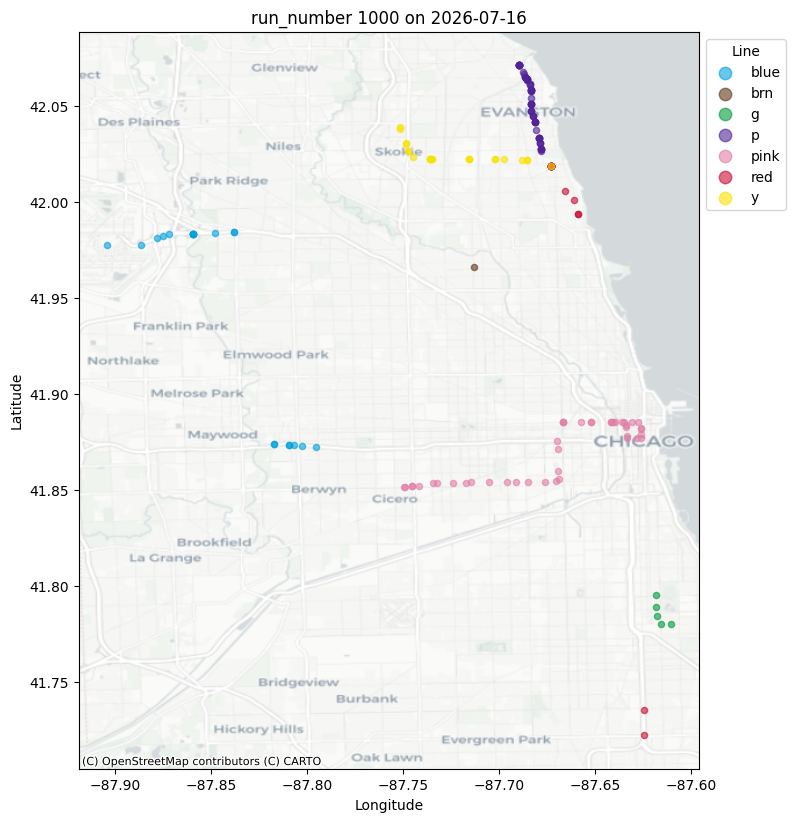

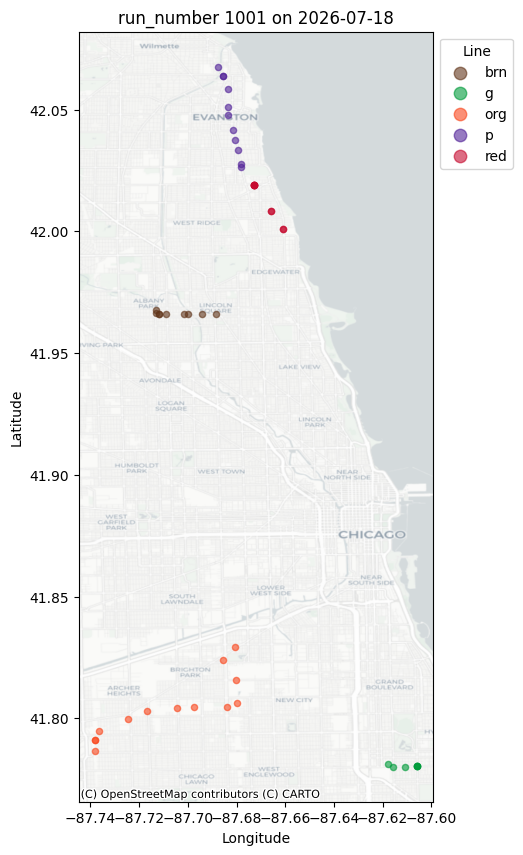

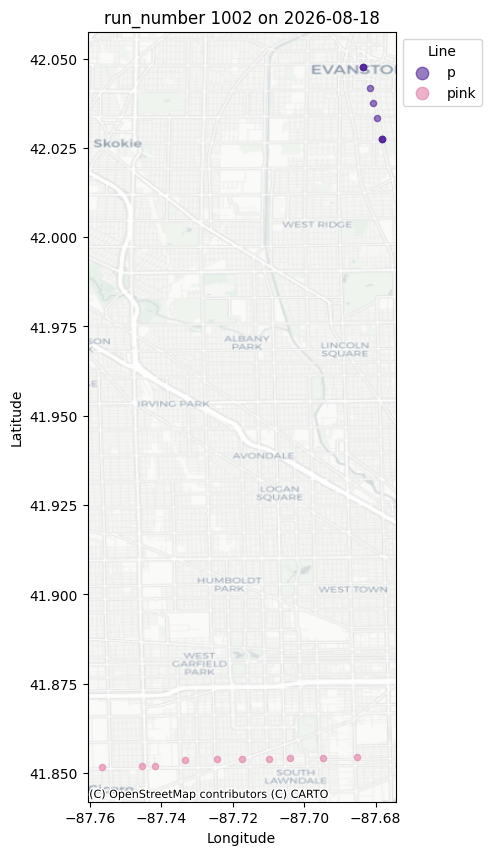

In [49]:
# one representative day per run_number, chosen from a day where it showed several lines
run_days = {
    "1000": "2026-07-16",  # 7 distinct lines this day
    "1001": "2026-07-18",  # 5 distinct lines this day
    "1002": "2026-08-18",  # the one day it showed more than 1 line
}

for run_number, day in run_days.items():
    day_positions = con.execute(f"""
        SELECT line, latitude, longitude
        FROM '{DATA_PATH}'
        WHERE run_number = '{run_number}'
            AND CAST(polled_at AS DATE) = '{day}'
            AND latitude != 0 AND longitude != 0
    """).df()

    _, ax = plt.subplots(figsize=(8, 10))

    for line, group in day_positions.groupby("line"):
        ax.scatter(
            group["longitude"], group["latitude"],
            s=20, alpha=0.6,
            color=CTA_LINE_COLORS.get(line, "#888888"),
            label=line,
        )

    cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal")
    ax.legend(markerscale=2, title="Line", loc="upper left", bbox_to_anchor=(1, 1))
    ax.set_title(f"run_number {run_number} on {day}")

    plt.show()

The visual plots of these `run_number` traces demonstrate that these are in fact not contiguous runs. For the purposes of our investigation into train delays, we will ignore these values.